# 1. Load file

In [3]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\ausgrid_pv_combined.parquet")

In [4]:
serials_one_vphase = (
    df.groupby('serial')['Vphase']
      .nunique()
      .loc[lambda s: s == 1]
      .index
)

serials_one_vphase

Index([326228801, 326612333, 361431370, 810021485, 810022184, 810029493,
       810029726, 810029855, 810029925, 810045702,
       ...
       811326387, 811326388, 811339438, 811355765, 811355885, 811356847,
       811357114, 811411119, 811411139, 811420217],
      dtype='int64', name='serial', length=613)

In [5]:
serials_one_vphase[0]

np.int64(326228801)

In [6]:
serials_one_vphase[0]

np.int64(326228801)

In [7]:
## GOOD SERIALS TO CHECK ##

SERIAL = 810584444  
s_rated = 8250 # Watts
# SERIAL = 811513156
# SERIAL = 811280075
SERIAL = serials_one_vphase[0]

In [8]:
df_serial = df.query('serial == @SERIAL').copy()

In [9]:
df_serial.to_csv(f"example_{SERIAL}.csv", index=False)

In [10]:
df_filtered = df[df['serial']==SERIAL].groupby(['serial', 'MeasureTime']).agg({
    'Volts': 'mean',
    'ReactPow': 'sum',
    'ActivePow': 'sum',
    'Curr': 'sum'
}).reset_index()

df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr
0,326228801,2024-08-01 00:00:00,239.906845,0.0,0.0,2.059603
1,326228801,2024-08-01 00:05:00,239.463669,0.0,0.0,2.482861
2,326228801,2024-08-01 00:10:00,239.267838,0.0,0.0,2.607571
3,326228801,2024-08-01 00:15:00,239.649185,0.0,0.0,2.702048
4,326228801,2024-08-01 00:20:00,240.514938,0.0,0.0,2.547106
...,...,...,...,...,...,...
104971,326228801,2025-07-31 23:35:00,236.691200,0.0,0.0,13.011402
104972,326228801,2025-07-31 23:40:00,236.990082,0.0,0.0,8.397135
104973,326228801,2025-07-31 23:45:00,236.670578,0.0,0.0,15.237286
104974,326228801,2025-07-31 23:50:00,237.021000,0.0,0.0,9.073592


In [11]:
df_filtered[df_filtered['MeasureTime'].duplicated(keep=False)]

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr


In [12]:
df_filtered['ApparentPow'] = ((df_filtered['ReactPow'] ** 2) + (df_filtered['ActivePow'] ** 2)) ** 0.5
df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
0,326228801,2024-08-01 00:00:00,239.906845,0.0,0.0,2.059603,0.0
1,326228801,2024-08-01 00:05:00,239.463669,0.0,0.0,2.482861,0.0
2,326228801,2024-08-01 00:10:00,239.267838,0.0,0.0,2.607571,0.0
3,326228801,2024-08-01 00:15:00,239.649185,0.0,0.0,2.702048,0.0
4,326228801,2024-08-01 00:20:00,240.514938,0.0,0.0,2.547106,0.0
...,...,...,...,...,...,...,...
104971,326228801,2025-07-31 23:35:00,236.691200,0.0,0.0,13.011402,0.0
104972,326228801,2025-07-31 23:40:00,236.990082,0.0,0.0,8.397135,0.0
104973,326228801,2025-07-31 23:45:00,236.670578,0.0,0.0,15.237286,0.0
104974,326228801,2025-07-31 23:50:00,237.021000,0.0,0.0,9.073592,0.0


In [11]:
# Choose a random 7-day window from the full-year data using MeasureTime
possible_starts = pd.date_range(
    start=df_filtered['MeasureTime'].min().normalize(),
    end=df_filtered['MeasureTime'].max().normalize() - pd.Timedelta(days=7),
    freq='D'
)

random_start = possible_starts.to_series().sample(1).iloc[0]

df_random_week = df_filtered[
    (df_filtered['MeasureTime'] >= random_start) &
    (df_filtered['MeasureTime'] < random_start + pd.Timedelta(days=7))
].copy()

df_random_week

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
864,810584444,2024-08-04 00:00:00,241.868541,939.356380,-3012.066772,15.448914,3155.144473
865,810584444,2024-08-04 00:05:00,240.927200,433.941850,-1751.082855,8.279983,1804.050081
866,810584444,2024-08-04 00:10:00,240.844752,668.780914,-602.413370,10.736391,900.094317
867,810584444,2024-08-04 00:15:00,240.690150,576.887362,403.310638,13.245706,703.888130
868,810584444,2024-08-04 00:20:00,241.686452,1730.662086,-1470.296970,12.803552,2270.895074
...,...,...,...,...,...,...,...
2875,810584444,2024-08-10 23:35:00,242.603744,1118.038318,-4017.790502,19.125968,4170.449640
2876,810584444,2024-08-10 23:40:00,242.844228,1485.612632,-4431.311797,21.276269,4673.710425
2877,810584444,2024-08-10 23:45:00,242.394174,1077.196820,-1495.822945,9.277663,1843.322889
2878,810584444,2024-08-10 23:50:00,240.793218,536.045758,-944.461605,5.449446,1085.980100


<Axes: title={'center': 'Power over Time for Serial 810584444 (Random Week Starting 2024-08-04)'}, xlabel='MeasureTime'>

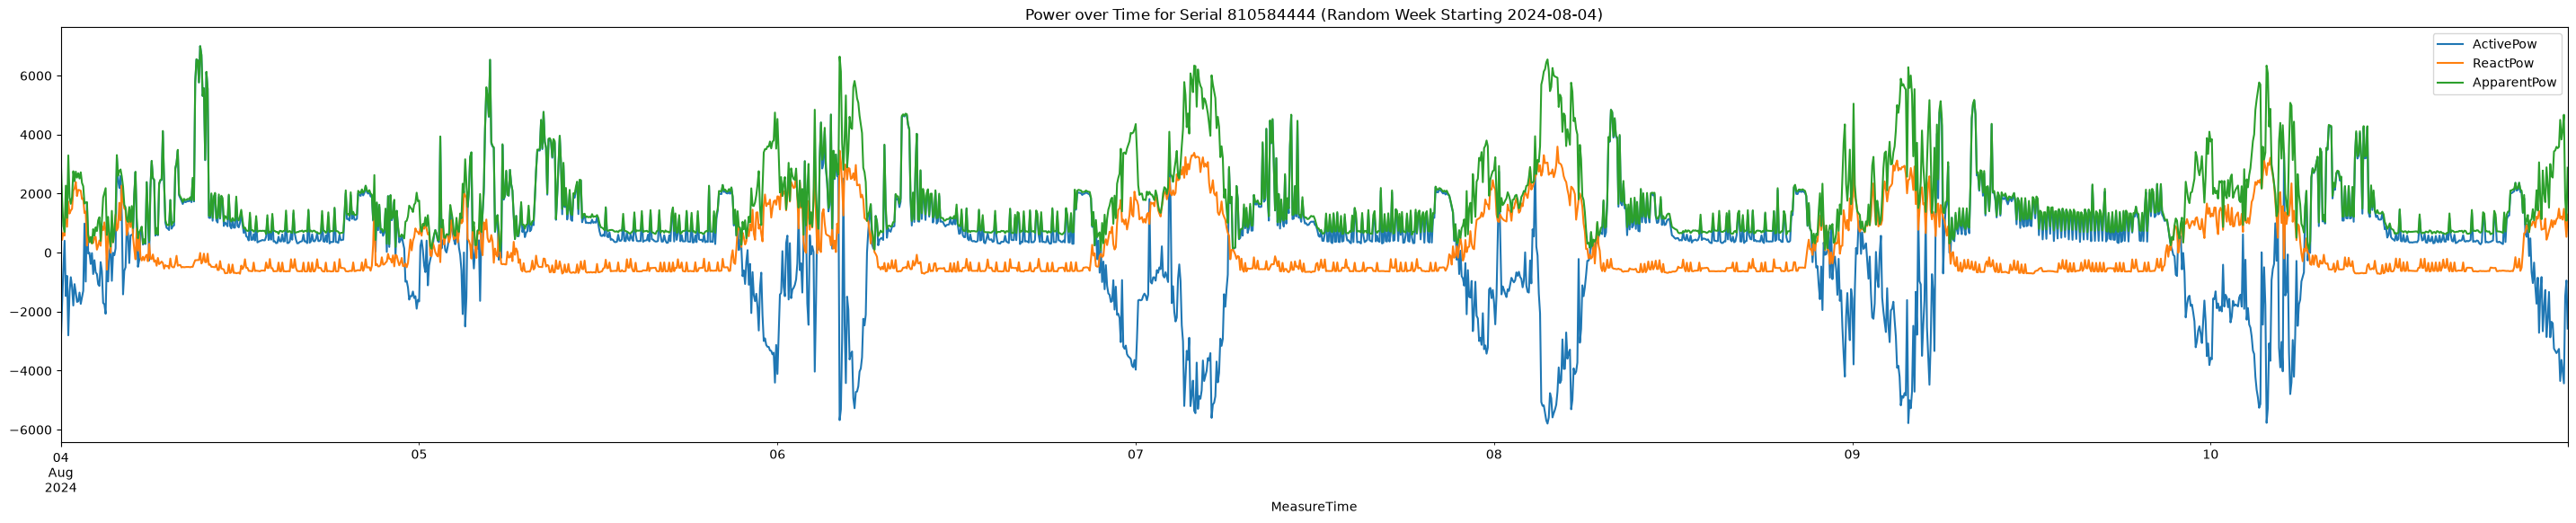

In [12]:
df_random_week.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(36, 6), kind='line', title=f'Power over Time for Serial 810584444 (Random Week Starting {random_start.date()})')

In [13]:
middle_day = random_start + pd.Timedelta(days=3)  # 4th day of the 7-day window

df_middle_day = df_random_week[
    (df_random_week['MeasureTime'] >= middle_day) &
    (df_random_week['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
1728,810584444,2024-08-07 00:00:00,244.345561,1807.240060,-3966.738634,20.501556,4359.028794
1729,810584444,2024-08-07 00:05:00,244.266541,1761.293273,-2920.173308,15.989324,3410.214970
1730,810584444,2024-08-07 00:10:00,244.510462,1608.137300,-1618.347752,11.666046,2281.480884
1731,810584444,2024-08-07 00:15:00,244.881500,1128.248742,-1597.926962,10.645692,1956.097083
1732,810584444,2024-08-07 00:20:00,243.383611,1174.195554,-1618.347707,10.691042,1999.446048
...,...,...,...,...,...,...,...
2011,810584444,2024-08-07 23:35:00,244.472677,1628.558103,-3221.379760,18.725384,3609.638355
2012,810584444,2024-08-07 23:40:00,243.960785,1470.297017,-1250.773453,11.363719,1930.338714
2013,810584444,2024-08-07 23:45:00,243.830233,2169.709133,-1194.616295,12.350062,2476.841903
2014,810584444,2024-08-07 23:50:00,243.936732,2139.077943,-1541.769804,13.854138,2636.798926


In [14]:
# df_middle_day.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(12, 6), kind='line', title=f'Power over Time for Serial 810584444 (Middle Day: {middle_day.date()})')

In [15]:
df_middle_day_full = df[
    (df['MeasureTime'] >= middle_day) &
    (df['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day_full

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
23133244,810787071,2024-08-07 00:00:00,A,245.905289,1.265995,-280.785900,51.05198,2024-08,jm_unswnmisaug24
23133245,810787071,2024-08-07 00:00:00,C,245.915600,15.823044,-20.420792,-3890.16100,2024-08,jm_unswnmisaug24
23133246,810787071,2024-08-07 00:00:00,B,247.451279,9.156732,-122.524750,-2246.28700,2024-08,jm_unswnmisaug24
23133247,810787071,2024-08-07 00:05:00,B,247.842941,8.948882,-51.051980,-2205.44556,2024-08,jm_unswnmisaug24
23133248,810787071,2024-08-07 00:05:00,A,245.781616,1.273553,-280.785900,51.05198,2024-08,jm_unswnmisaug24
...,...,...,...,...,...,...,...,...,...
47511692,811513156,2024-08-07 23:45:00,A,239.010178,3.998276,-301.206665,-893.40960,2024-08,jm_unswnmisaug24
47511693,811513156,2024-08-07 23:50:00,B,238.329941,0.000000,0.000000,0.00000,2024-08,jm_unswnmisaug24
47511694,811513156,2024-08-07 23:50:00,A,238.329941,4.330835,-245.049500,-990.40840,2024-08,jm_unswnmisaug24
47511695,811513156,2024-08-07 23:55:00,B,238.742200,0.000000,0.000000,0.00000,2024-08,jm_unswnmisaug24


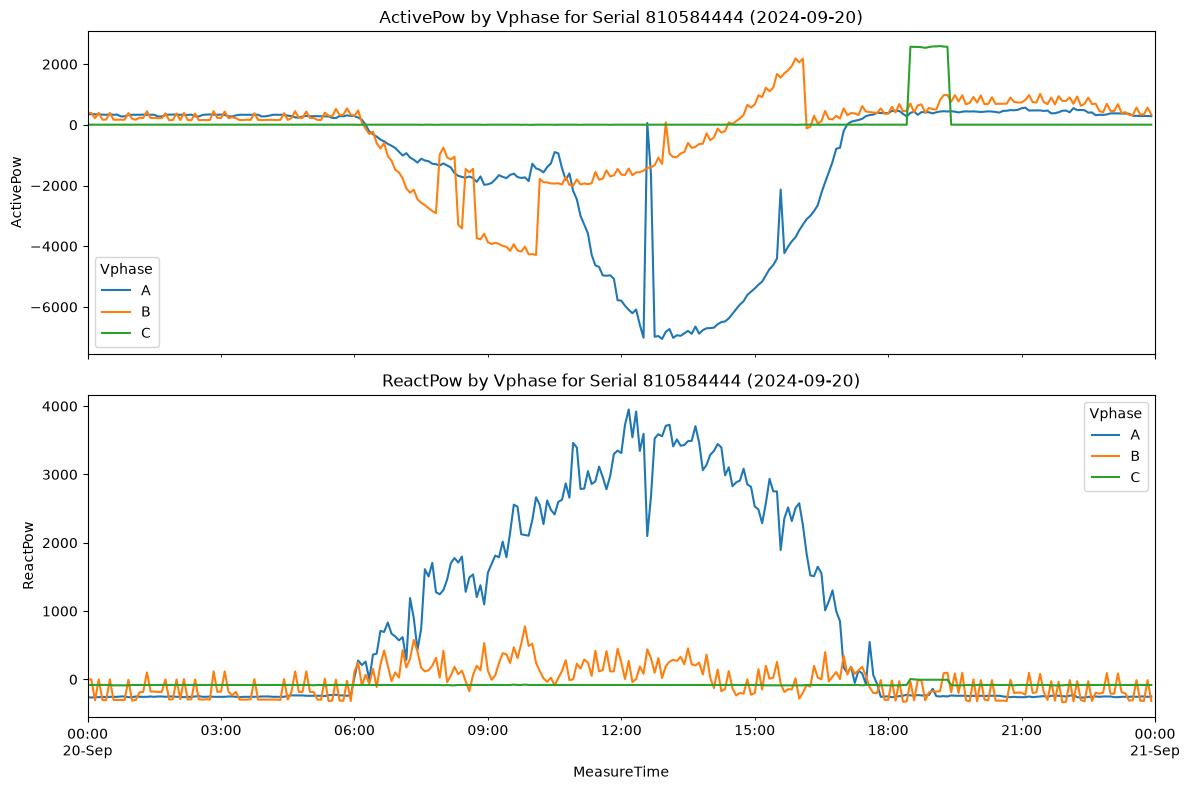

In [16]:
import matplotlib.pyplot as plt

# 2024-09-20 in Australia/Sydney time
day_start = pd.Timestamp("2024-09-20", tz="Australia/Sydney")
day_end = day_start + pd.Timedelta(days=1)

# Prepare one-day subset
df_day = df.copy()
df_day["MeasureTime"] = pd.to_datetime(df_day["MeasureTime"], utc=True).dt.tz_convert("Australia/Sydney")

df_day = df_day[
    (df_day["serial"] == SERIAL) &
    (df_day["MeasureTime"] >= day_start) &
    (df_day["MeasureTime"] < day_end)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, metric in zip(axes, ["ActivePow", "ReactPow"]):
    (
        df_day
        .pivot_table(index="MeasureTime", columns="Vphase", values=metric, aggfunc="mean")
        .sort_index()
        .plot(ax=ax)
    )
    ax.set_title(f"{metric} by Vphase for Serial {SERIAL} ({day_start.date()})")
    ax.set_ylabel(metric)
    ax.set_xlim(day_start, day_end)

axes[-1].set_xlabel("MeasureTime")
plt.tight_layout()
plt.show()

In [17]:
# Convert to Australia/Sydney time and filter to one local day (00:00 -> midnight)
df_oneserial = df.copy()
df_oneserial['MeasureTime'] = pd.to_datetime(df_oneserial['MeasureTime'], utc=True).dt.tz_convert('Australia/Sydney')


df_oneserial['ApparentPow'] = ((df_oneserial['ReactPow'] ** 2) + (df_oneserial['ActivePow'] ** 2)) ** 0.5
df_oneserial

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file,ApparentPow
0,810813941,2025-04-02 20:40:00+11:00,C,240.051147,1.719485,-193.997528,265.470276,2025-04,jm_unswnmisapr25,328.800104
1,810813941,2025-04-02 20:40:00+11:00,B,233.825958,0.411921,-86.788360,35.736385,2025-04,jm_unswnmisapr25,93.857917
2,810813941,2025-04-02 20:40:00+11:00,A,235.732666,2.649141,-112.314354,607.518555,2025-04,jm_unswnmisapr25,617.813328
3,810813941,2025-04-02 20:45:00+11:00,C,239.834700,1.761055,-193.997528,270.575500,2025-04,jm_unswnmisapr25,332.935643
4,810813941,2025-04-02 20:45:00+11:00,A,234.557724,2.399721,-91.893560,551.361400,2025-04,jm_unswnmisapr25,558.966743
...,...,...,...,...,...,...,...,...,...,...
303647628,811513156,2024-10-01 09:45:00+10:00,A,242.277374,10.687262,342.048248,-2557.704000,2024-09,jm_unswnmissep24,2580.474134
303647629,811513156,2024-10-01 09:50:00+10:00,B,240.514938,0.000000,0.000000,0.000000,2024-09,jm_unswnmissep24,0.000000
303647630,811513156,2024-10-01 09:50:00+10:00,A,240.514938,10.849764,-76.577970,-2588.335450,2024-09,jm_unswnmissep24,2589.468012
303647631,811513156,2024-10-01 09:55:00+10:00,A,240.112976,11.522441,51.051980,-2751.701660,2024-09,jm_unswnmissep24,2752.175200


In [13]:
SERIAL = 810208902

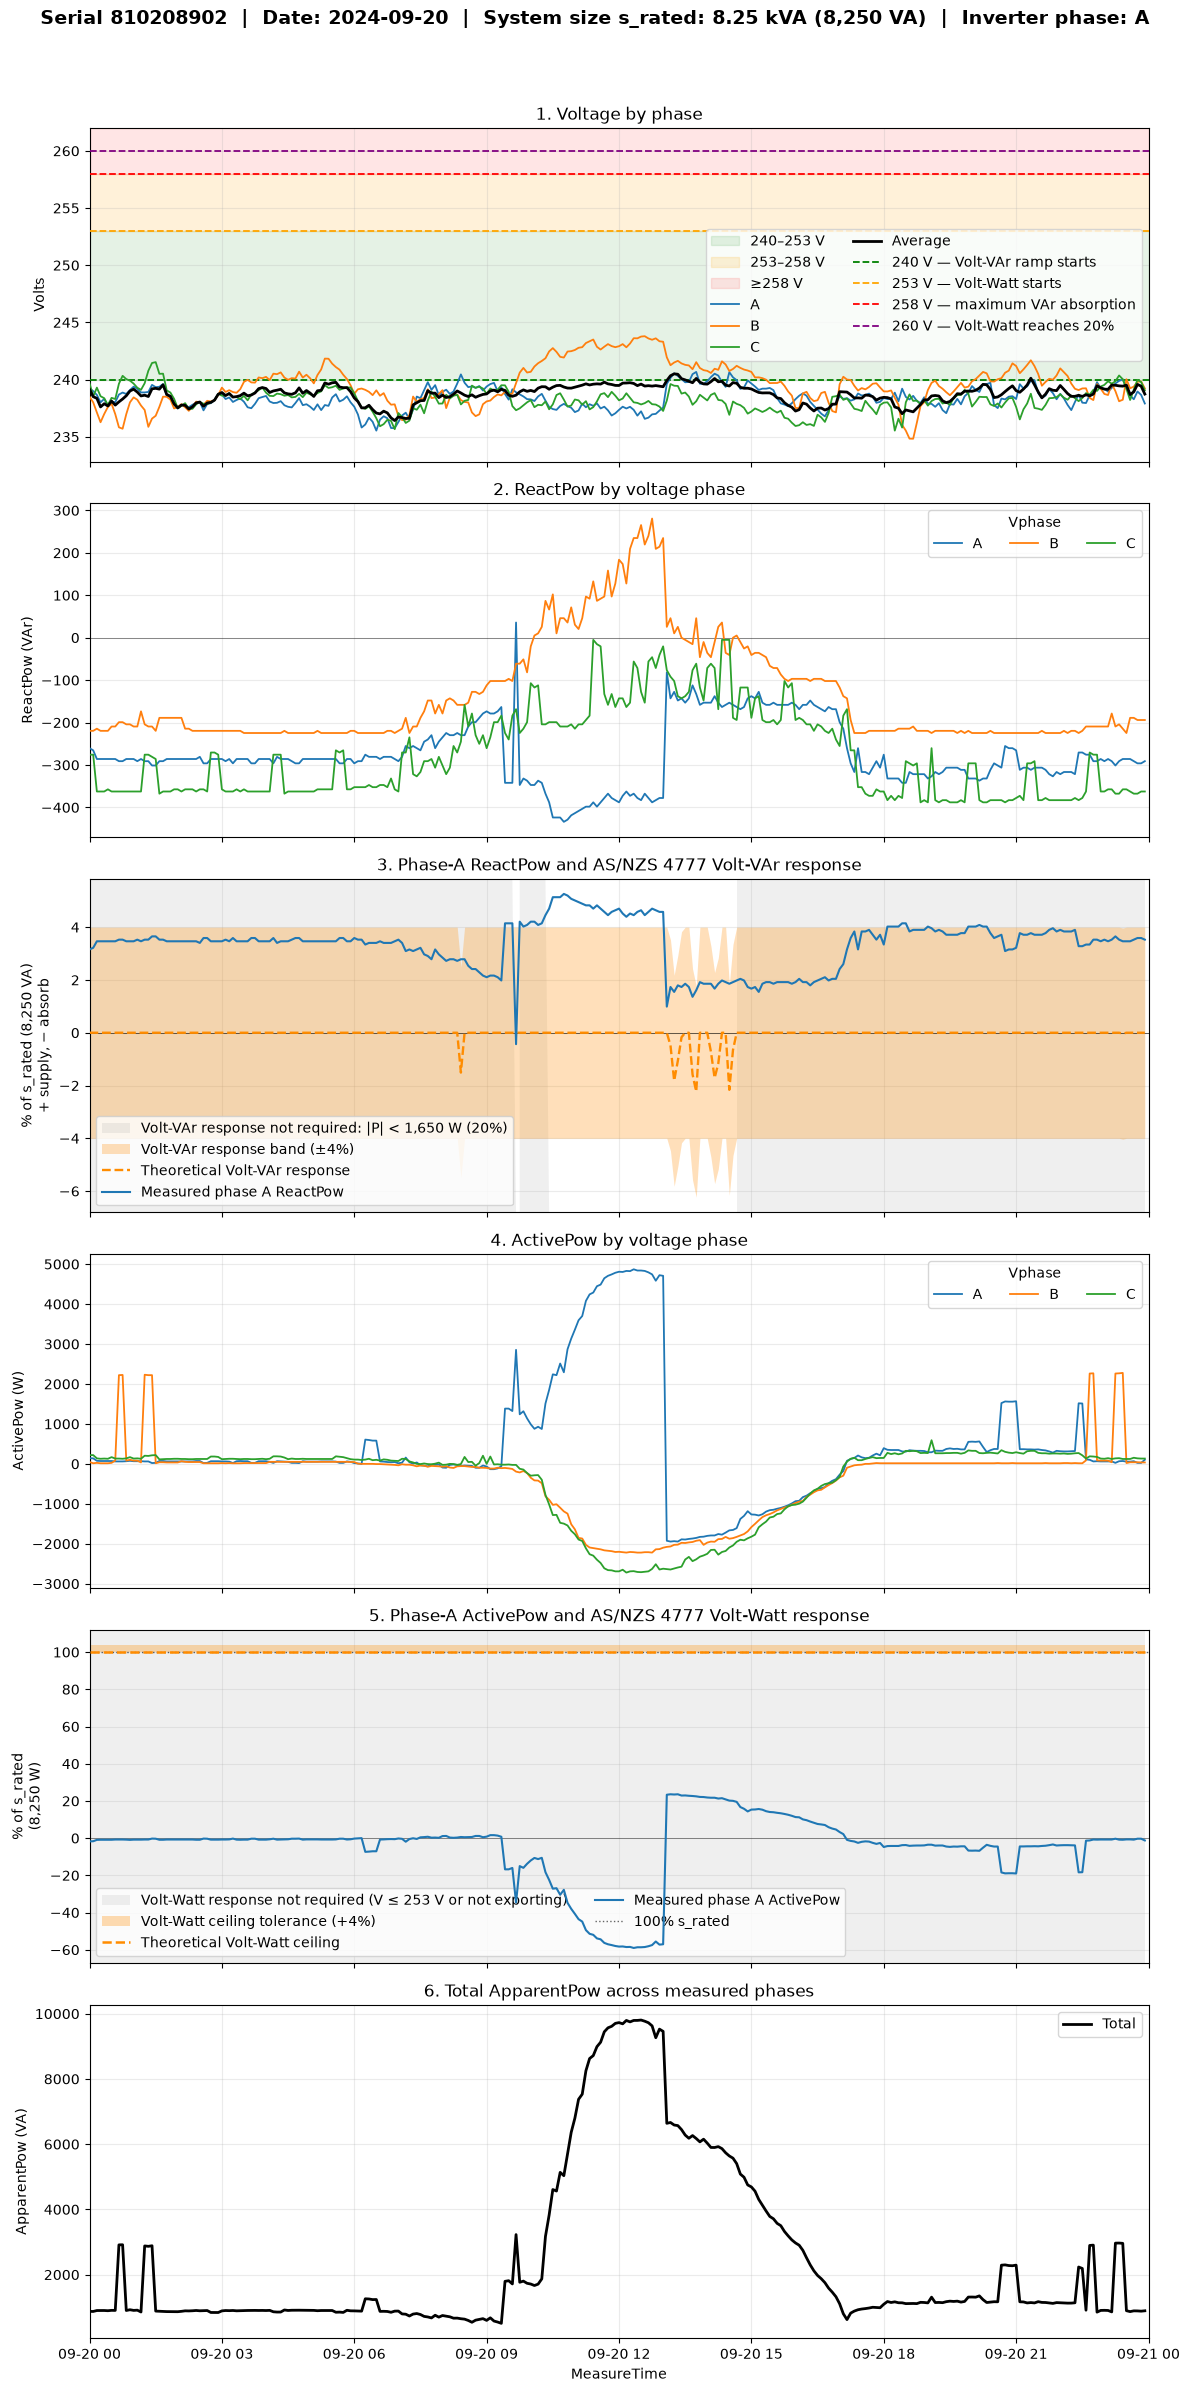

In [14]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Import AS/NZS 4777 curve definitions
# ---------------------------------------------------------------------------

PROJECT_SRC = Path(
    r'C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA'
    r'\ausgrid_analysis\src'
)

if str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

from ausgrid_analysis.as4777_curves import (
    Q_CAPABILITY,
    TOLERANCE_FRACTION,
    VOLT_VAR,
    VOLT_WATT,
    classify_voltvar_interval,
    vvar_required_q,
    vw_max_p,
)


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

day_start = pd.Timestamp(
    '2024-09-20',
    tz='Australia/Sydney'
)
day_end = day_start + pd.Timedelta(days=1)

INVERTER_PHASE = 'A'

# Full rating of the single-phase inverter connected to phase A.
s_rated = 8250.0  # VA; also used as the W/VAr response basis

# Set to -1.0 if inverter generation is stored as negative ActivePow.
ACTIVE_GENERATION_SIGN = -1.0

# as4777_curves.py uses:
#   +Q = supplying reactive power
#   -Q = absorbing reactive power
#
# Set to -1.0 if ReactPow uses the opposite convention.
REACTIVE_GENERATOR_SIGN = -1.0

reactive_activation_power = (
    Q_CAPABILITY.p_min * s_rated
)

tolerance_pct = (
    100.0 * TOLERANCE_FRACTION
)


# ---------------------------------------------------------------------------
# Prepare data
# ---------------------------------------------------------------------------

df_oneserial = df.copy()

df_oneserial['MeasureTime'] = (
    pd.to_datetime(
        df_oneserial['MeasureTime'],
        utc=True
    )
    .dt.tz_convert('Australia/Sydney')
)

df_oneserial['ApparentPow'] = np.hypot(
    df_oneserial['ActivePow'],
    df_oneserial['ReactPow']
)

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == SERIAL)
    & (df_oneserial['MeasureTime'] >= day_start)
    & (df_oneserial['MeasureTime'] < day_end)
].copy()

if df_oneserial.empty:
    raise ValueError(
        f'No data found for serial {SERIAL} on {day_start.date()}'
    )

available_phases = sorted(
    df_oneserial['Vphase'].dropna().unique()
)

if INVERTER_PHASE not in available_phases:
    raise ValueError(
        f'Inverter phase {INVERTER_PHASE!r} was not found. '
        f'Available phases: {available_phases}'
    )


# ---------------------------------------------------------------------------
# Pivot raw measurements by phase
# ---------------------------------------------------------------------------

def pivot_metric(metric):
    return (
        df_oneserial
        .pivot_table(
            index='MeasureTime',
            columns='Vphase',
            values=metric,
            aggfunc='mean'
        )
        .sort_index()
    )


pivot_active = pivot_metric('ActivePow')
pivot_reactive = pivot_metric('ReactPow')
pivot_volts = pivot_metric('Volts')


# ---------------------------------------------------------------------------
# Prepare inverter-phase measurements
# ---------------------------------------------------------------------------

phase_data = (
    df_oneserial.loc[
        df_oneserial['Vphase'] == INVERTER_PHASE,
        [
            'MeasureTime',
            'ActivePow',
            'ReactPow',
            'Volts'
        ]
    ]
    .groupby('MeasureTime')
    .agg(
        ActivePow=('ActivePow', 'mean'),
        ReactPow=('ReactPow', 'mean'),
        Volts=('Volts', 'mean')
    )
    .sort_index()
)

phase_data['ActiveGeneration'] = (
    ACTIVE_GENERATION_SIGN
    * phase_data['ActivePow']
)

phase_data['ReactiveGenerator'] = (
    REACTIVE_GENERATOR_SIGN
    * phase_data['ReactPow']
)

phase_data['ActivePow_pct_s_rated'] = (
    100.0
    * phase_data['ActiveGeneration']
    / s_rated
)

phase_data['ReactPow_pct_s_rated'] = (
    100.0
    * phase_data['ReactiveGenerator']
    / s_rated
)

plot_times = phase_data.index.to_pydatetime()


# ---------------------------------------------------------------------------
# Volt-Watt response
# ---------------------------------------------------------------------------

phase_data['VW_ceiling_pct'] = (
    phase_data['Volts']
    .map(lambda voltage: vw_max_p(voltage, 1.0))
    * 100.0
)

phase_data['VW_upper_tolerance_pct'] = (
    phase_data['VW_ceiling_pct']
    + tolerance_pct
)

phase_data['VW_response_required'] = (
    (phase_data['Volts'] > VOLT_WATT.v1)
    & (phase_data['ActiveGeneration'] > 0)
)

vw_not_required_mask = (
    phase_data['Volts'].notna()
    & ~phase_data['VW_response_required']
).to_numpy(dtype=bool)


# ---------------------------------------------------------------------------
# Volt-VAr response
# ---------------------------------------------------------------------------

phase_data['VV_required_pct'] = (
    phase_data['Volts']
    .map(lambda voltage: vvar_required_q(voltage, 1.0))
    * 100.0
)

phase_data['VV_response_required'] = (
    phase_data['ActiveGeneration'].notna()
    & (
        phase_data['ActiveGeneration'].abs()
        >= reactive_activation_power
    )
)

vv_not_required_mask = (
    phase_data['ActiveGeneration'].notna()
    & ~phase_data['VV_response_required']
).to_numpy(dtype=bool)


def calculate_voltvar_band(row):
    voltage = row['Volts']
    active_power = row['ActiveGeneration']
    reactive_power = row['ReactiveGenerator']
    response_required = row['VV_response_required']

    if pd.isna(voltage):
        return pd.Series({
            'VV_lower_pct': np.nan,
            'VV_upper_pct': np.nan
        })

    theoretical_q_pct = (
        100.0 * vvar_required_q(voltage, 1.0)
    )

    if (
        not response_required
        or pd.isna(active_power)
        or pd.isna(reactive_power)
    ):
        # Show the theoretical response band even when it is not mandatory.
        return pd.Series({
            'VV_lower_pct': theoretical_q_pct - tolerance_pct,
            'VV_upper_pct': theoretical_q_pct + tolerance_pct
        })

    result = classify_voltvar_interval(
        voltage_v=float(voltage),
        active_power=float(active_power),
        q_generator=float(reactive_power),
        capacity=float(s_rated),
        capability_profile='review_corrected',
        tolerance_fraction=TOLERANCE_FRACTION
    )

    return pd.Series({
        'VV_lower_pct': (
            100.0 * result.q_min_final / s_rated
            if result.q_min_final is not None
            else np.nan
        ),
        'VV_upper_pct': (
            100.0 * result.q_max_final / s_rated
            if result.q_max_final is not None
            else np.nan
        )
    })


voltvar_band = phase_data.apply(
    calculate_voltvar_band,
    axis=1
)

phase_data = pd.concat(
    [phase_data, voltvar_band],
    axis=1
)


# ---------------------------------------------------------------------------
# Total apparent power
# ---------------------------------------------------------------------------

total_apparent = (
    df_oneserial
    .pivot_table(
        index='MeasureTime',
        columns='Vphase',
        values='ApparentPow',
        aggfunc='mean'
    )
    .sort_index()
    .sum(axis=1, min_count=1)
)


# ---------------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(
    6,
    1,
    figsize=(12, 24),
    sharex=True
)

metadata_title = (
    f'Serial {SERIAL}  |  Date: {day_start.date()}  |  '
    f'System size s_rated: {s_rated / 1000:.2f} kVA '
    f'({s_rated:,.0f} VA)  |  '
    f'Inverter phase: {INVERTER_PHASE}'
)

fig.suptitle(
    metadata_title,
    fontsize=14,
    fontweight='bold',
    y=0.995
)

palette = plt.cm.tab10.colors

phase_colors = {
    phase: palette[i % len(palette)]
    for i, phase in enumerate(available_phases)
}


def draw_measured_phases(
    ax,
    pivoted,
    title,
    ylabel,
    *,
    linewidth=1.3
):
    for phase in pivoted.columns:
        ax.plot(
            pivoted.index.to_pydatetime(),
            pivoted[phase].to_numpy(),
            color=phase_colors[phase],
            linewidth=linewidth,
            zorder=6,
            label=str(phase)
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlim(
        day_start.to_pydatetime(),
        day_end.to_pydatetime()
    )
    ax.grid(True, alpha=0.25)


# ===========================================================================
# SUBPLOT 1: VOLTAGE
# ===========================================================================

voltage_values = pivot_volts.to_numpy(dtype=float)

voltage_axis_min = min(
    235,
    np.nanmin(voltage_values) - 2
)

voltage_axis_max = max(
    262,
    np.nanmax(voltage_values) + 2
)

axes[0].axhspan(
    240,
    253,
    color='green',
    alpha=0.10,
    label='240–253 V'
)

axes[0].axhspan(
    253,
    258,
    color='orange',
    alpha=0.15,
    label='253–258 V'
)

axes[0].axhspan(
    258,
    voltage_axis_max,
    color='red',
    alpha=0.10,
    label='≥258 V'
)

draw_measured_phases(
    axes[0],
    pivot_volts,
    '1. Voltage by phase',
    'Volts'
)

voltage_average = pivot_volts.mean(axis=1)

axes[0].plot(
    voltage_average.index.to_pydatetime(),
    voltage_average.to_numpy(),
    color='black',
    linewidth=2,
    zorder=7,
    label='Average'
)

for voltage, color, label in [
    (
        VOLT_VAR.v3,
        'green',
        f'{VOLT_VAR.v3:.0f} V — Volt-VAr ramp starts'
    ),
    (
        VOLT_WATT.v1,
        'orange',
        f'{VOLT_WATT.v1:.0f} V — Volt-Watt starts'
    ),
    (
        VOLT_VAR.v4,
        'red',
        f'{VOLT_VAR.v4:.0f} V — maximum VAr absorption'
    ),
    (
        VOLT_WATT.v2,
        'purple',
        f'{VOLT_WATT.v2:.0f} V — Volt-Watt reaches 20%'
    )
]:
    axes[0].axhline(
        voltage,
        color=color,
        linestyle='--',
        linewidth=1.3,
        zorder=4,
        label=label
    )

axes[0].set_ylim(
    voltage_axis_min,
    voltage_axis_max
)
axes[0].legend(ncol=2)


# ===========================================================================
# SUBPLOT 2: REACTIVE POWER
# ===========================================================================

draw_measured_phases(
    axes[1],
    pivot_reactive,
    '2. ReactPow by voltage phase',
    'ReactPow (VAr)'
)

axes[1].axhline(
    0,
    color='black',
    linewidth=0.6,
    alpha=0.5
)

axes[1].legend(
    title='Vphase',
    ncol=len(pivot_reactive.columns)
)


# ===========================================================================
# SUBPLOT 3: REACTIVE POWER AS % OF S_RATED
# ===========================================================================

axes[2].fill_between(
    plot_times,
    0,
    1,
    where=vv_not_required_mask,
    interpolate=True,
    transform=axes[2].get_xaxis_transform(),
    color='grey',
    alpha=0.12,
    linewidth=0,
    zorder=1,
    label=(
        f'Volt-VAr response not required: '
        f'|P| < {reactive_activation_power:,.0f} W '
        f'({Q_CAPABILITY.p_min * 100:.0f}%)'
    )
)

axes[2].fill_between(
    plot_times,
    phase_data['VV_lower_pct'].to_numpy(),
    phase_data['VV_upper_pct'].to_numpy(),
    color='darkorange',
    alpha=0.27,
    linewidth=0,
    zorder=2,
    label=(
        f'Volt-VAr response band '
        f'(±{tolerance_pct:.0f}%)'
    )
)

axes[2].plot(
    plot_times,
    phase_data['VV_required_pct'].to_numpy(),
    color='darkorange',
    linewidth=1.7,
    linestyle='--',
    zorder=4,
    label='Theoretical Volt-VAr response'
)

axes[2].plot(
    plot_times,
    phase_data['ReactPow_pct_s_rated'].to_numpy(),
    color=phase_colors[INVERTER_PHASE],
    linewidth=1.5,
    zorder=7,
    label=f'Measured phase {INVERTER_PHASE} ReactPow'
)

axes[2].axhline(
    0,
    color='black',
    linewidth=0.7,
    alpha=0.6,
    zorder=3
)

axes[2].set_title(
    '3. Phase-A ReactPow and AS/NZS 4777 Volt-VAr response'
)
axes[2].set_ylabel(
    f'% of s_rated ({s_rated:,.0f} VA)\n'
    f'+ supply, − absorb'
)
axes[2].set_xlim(
    day_start.to_pydatetime(),
    day_end.to_pydatetime()
)
axes[2].grid(True, alpha=0.25)
axes[2].legend(ncol=1)


# ===========================================================================
# SUBPLOT 4: ACTIVE POWER
# ===========================================================================

draw_measured_phases(
    axes[3],
    pivot_active,
    '4. ActivePow by voltage phase',
    'ActivePow (W)'
)

axes[3].legend(
    title='Vphase',
    ncol=len(pivot_active.columns)
)


# ===========================================================================
# SUBPLOT 5: ACTIVE POWER AS % OF S_RATED
# ===========================================================================

axes[4].fill_between(
    plot_times,
    0,
    1,
    where=vw_not_required_mask,
    interpolate=True,
    transform=axes[4].get_xaxis_transform(),
    color='grey',
    alpha=0.12,
    linewidth=0,
    zorder=1,
    label=(
        f'Volt-Watt response not required '
        f'(V ≤ {VOLT_WATT.v1:.0f} V or not exporting)'
    )
)

axes[4].fill_between(
    plot_times,
    phase_data['VW_ceiling_pct'].to_numpy(),
    phase_data['VW_upper_tolerance_pct'].to_numpy(),
    color='darkorange',
    alpha=0.30,
    linewidth=0,
    zorder=2,
    label=(
        f'Volt-Watt ceiling tolerance '
        f'(+{tolerance_pct:.0f}%)'
    )
)

axes[4].plot(
    plot_times,
    phase_data['VW_ceiling_pct'].to_numpy(),
    color='darkorange',
    linewidth=1.8,
    linestyle='--',
    zorder=4,
    label='Theoretical Volt-Watt ceiling'
)

axes[4].plot(
    plot_times,
    phase_data['ActivePow_pct_s_rated'].to_numpy(),
    color=phase_colors[INVERTER_PHASE],
    linewidth=1.5,
    zorder=7,
    label=f'Measured phase {INVERTER_PHASE} ActivePow'
)

axes[4].axhline(
    100,
    color='black',
    linestyle=':',
    linewidth=1,
    alpha=0.6,
    zorder=3,
    label='100% s_rated'
)

axes[4].axhline(
    0,
    color='black',
    linewidth=0.6,
    alpha=0.5,
    zorder=3
)

axes[4].set_title(
    '5. Phase-A ActivePow and AS/NZS 4777 Volt-Watt response'
)
axes[4].set_ylabel(
    f'% of s_rated\n({s_rated:,.0f} W)'
)
axes[4].set_xlim(
    day_start.to_pydatetime(),
    day_end.to_pydatetime()
)
axes[4].grid(True, alpha=0.25)  
axes[4].legend(ncol=2)


# ===========================================================================
# SUBPLOT 6: TOTAL APPARENT POWER
# ===========================================================================

axes[5].plot(
    total_apparent.index.to_pydatetime(),
    total_apparent.to_numpy(),
    color='black',
    linewidth=2,
    label='Total'
)

axes[5].set_title(
    '6. Total ApparentPow across measured phases'
)
axes[5].set_ylabel('ApparentPow (VA)')
axes[5].set_xlabel('MeasureTime')
axes[5].set_xlim(
    day_start.to_pydatetime(),
    day_end.to_pydatetime()
)
axes[5].grid(True, alpha=0.25)
axes[5].legend()


plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)
plt.show()